In [1]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
transcript_info = pd.read_csv(
    "BECancerResistome/data/TranscriptInfoBiomartExport17122024.txt.gz", sep="\t"
)
transcript_length = transcript_info.groupby("Transcript stable ID version")[
    "Transcript length (including UTRs and CDS)"
].first()

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_81958/585090872.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  transcript_info = pd.read_csv(


In [3]:
transcript_info.sample(5)

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Transcript length (including UTRs and CDS),Chromosome/scaffold name,Gene start (bp),Gene end (bp),Strand,Transcript start (bp),Transcript end (bp),Transcript type,Gene type,Gene % GC content,Transcript count
40036,ENSG00000197008,ENSG00000197008.10,ENST00000440155,ENST00000440155.6,1066,7,64794388,64833681,1,64794425,64832242,protein_coding,protein_coding,39.99,7
2939,ENSG00000291544,ENSG00000291544.1,ENST00000707961,ENST00000707961.1,14121,HG2231_HG2496_PATCH,52097,94741,-1,52097,94741,protein_coding,protein_coding,42.97,4
16399,ENSG00000064115,ENSG00000064115.11,ENST00000543088,ENST00000543088.5,601,12,26971579,27014434,-1,26995361,27014434,protein_coding,protein_coding,40.31,19
64720,ENSG00000122970,ENSG00000122970.16,ENST00000242591,ENST00000242591.10,3124,12,110124335,110218793,1,110124357,110218793,protein_coding,protein_coding,39.91,9
26869,ENSG00000064601,ENSG00000064601.21,ENST00000372459,ENST00000372459.7,1996,20,45890144,45898949,1,45891386,45898820,protein_coding,protein_coding,56.09,40


## Import DepMap


In [4]:
samplesheet = pd.read_csv("data/depmap/model_list_20241120.csv", index_col=0)

In [5]:
crispr = pd.read_csv(
    "data/depmap/20231023_092657_imputed_crisprcas9.csv.gz", index_col=0
)
crispr.sample(5)

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
SIDM01154,-0.03927,0.00991,0.03176,0.04285,-0.01711,-0.04159,0.04351,-0.11465,0.04218,0.05613,...,-0.11738,-0.26385,0.02270,0.09037,-0.02703,-0.01287,-0.04302,0.00489,-0.01057,-0.01058
SIDM01859,-0.03439,-0.02226,0.01584,0.07266,-0.08936,-0.04312,0.03680,-0.11780,0.03749,0.06385,...,-0.06001,-0.27129,0.02775,0.03739,-0.04101,-0.01573,-0.07542,0.00965,-0.07258,-0.18659
SIDM00831,-0.00398,-0.05416,0.01881,0.08160,-0.04792,-0.00552,0.00364,-0.10199,0.01502,0.04751,...,-0.11294,-0.57314,-0.00190,0.02005,-0.01264,-0.02206,-0.12351,0.03334,-0.06258,-0.18928
SIDM01628,-0.01483,-0.04281,-0.01707,0.10449,-0.09714,-0.07352,0.06035,-0.11837,0.06038,0.10544,...,-0.05565,-0.29200,0.01833,0.01676,0.01851,-0.01073,-0.13127,0.06830,-0.07301,-0.21495
SIDM00306,0.00608,-0.03506,0.04528,0.01370,-0.09785,-0.02266,0.03207,-0.11423,0.05402,0.09465,...,-0.09059,-0.30078,-0.00417,-0.00690,0.01983,-0.01117,-0.09459,-0.02067,-0.04894,-0.24417


## Import Coelho et at. dataset


In [6]:
be_coelho = pd.read_excel(
    "data/41588_2024_1948_MOESM4_ESM.xlsx", sheet_name="ST2 BE z-scores"
)

In [7]:
be_coelho.sample(5)

,Gene,CRISPR.PAM.Sequence,guide,Location,chr,start_end,start,end,Gene_ID,G_guide,...,cluster,energy_distance,diffusion_score,PFS_outcome_score,amplicon_seq_edit,consequence_amp_seq,HT29_inferred_ploidy,HT29_existing_SNVs,mean_vaf,experimentally_validated_gRNA
15425,MAP2K2,TGGCGTCGGGCGGGGGGATGGGG,TGGCGTCGGGCGGGGGGATG,19:4099303-4099325,19.0,4099303-4099325,4099303.0,4099325.0,ENSG00000126934,GGGCGTCGGGCGGGGGGATG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
24684,BCL2,TTCTGTGAAGCAGAAGTCTGGGA,TTCTGTGAAGCAGAAGTCTG,18:63319357-63319379,18.0,63319357-63319379,63319357.0,63319379.0,ENSG00000171791,GTCTGTGAAGCAGAAGTCTG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43082,PIK3CA,AAGTGCTATCAAACCCTGTTTGC,AAGTGCTATCAAACCCTGTT,3:179234530-179234552,3.0,179234530-179234552,179234530.0,179234552.0,ENSG00000121879,GAGTGCTATCAAACCCTGTT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34855,KRAS,AAAGTATCACTGGACTAGGAAGA,AAAGTATCACTGGACTAGGA,12:25208283-25208305,12.0,25208283-25208305,25208283.0,25208305.0,ENSG00000133703,GAAGTATCACTGGACTAGGA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7291,BRAF,CCTGGGCACAGCTTCATTTGAGA,CCTGGGCACAGCTTCATTTG,7:140724053-140724075,7.0,140724053-140724075,140724053.0,140724075.0,ENSG00000157764,GCTGGGCACAGCTTCATTTG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [8]:
be_coelho_info = be_coelho.groupby(["guide", "editor"])[
    ["Gene", "perfect_matches", "one_mismatch"]
].first()

In [9]:
be_coelho = be_coelho.set_index(["guide", "editor"])[
    [c for c in be_coelho if "average_zscore" in c]
]
be_coelho.sample(15)

,,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,L2FC_PC9_Osim_plasmid_average_zscore,L2FC_PC9_Gefit_plasmid_average_zscore,L2FC_MHHES1_Olap_plasmid_average_zscore,L2FC_MHHES1_Nirap_plasmid_average_zscore,L2FC_MHHES1_Control_plasmid_average_zscore
guide,editor,,,,,,,,,,,,,
TAACCCAGTTAGCTCTGTGG,ABE,-2.145233,-1.564625,-1.968380,-1.984218,-1.985752,-2.588056,-2.120946,-2.065850,-1.392866,-1.803095,-1.609422,-1.237601,-1.878600
TGTACATTACTAACTATAAG,CBE,0.043286,-0.053344,-0.251053,0.421764,-0.286703,-0.034590,-1.054021,-0.641970,-1.090705,-0.573595,NaN,NaN,NaN
GCACTCTGAAAAAGAAACAG,CBE,-0.839628,-0.626961,-0.830684,-0.180841,-0.616433,-0.590868,-0.760550,-0.747138,-0.708789,0.277933,NaN,NaN,NaN
TCTGTGGATGATTGACTTGG,CBE,-0.122026,-0.270390,-1.066885,-0.590503,0.215361,-0.696742,-0.066117,-0.375226,-0.191908,0.043398,NaN,NaN,NaN
GGTGAAGGCTGGGAACGTGA,CBE,0.203550,0.322755,0.050697,0.693471,0.476840,0.534815,0.635459,0.380932,0.377230,0.139211,NaN,NaN,NaN
TTCCTTACGCACAAGAGTTC,ABE,-0.106544,-0.431202,-0.519953,-1.062681,-1.449589,-1.692085,-1.985825,-0.725754,-1.281997,-0.675508,-0.359361,-1.458116,-0.732594
AACGTGCGGTTCGGCAGCCC,CBE,0.606388,0.633295,0.617369,0.516675,0.614529,1.423256,0.919803,0.312893,0.288230,0.125055,NaN,NaN,NaN
TTACCTGGCTCACTAACTAA,ABE,-0.622785,-0.270203,-0.007155,0.141005,0.191120,0.107558,0.039170,-0.845202,-0.709492,-0.688938,0.721031,-0.007918,-0.023450
CCGTCCTAGAGGGCACACAA,CBE,-1.530446,-1.414658,-0.943890,-0.617731,-1.867142,-1.194292,-0.981757,-0.412353,-0.914327,0.060631,NaN,NaN,NaN


### Unsupervised exploration of the dataset


In [60]:
bs_fcs = be_coelho.dropna(axis=1)

In [61]:
bs_fcs = bs_fcs.drop(("ATCACGCAGCTCATGCCCTT", "CBE"))

In [62]:
bs_fcs = bs_fcs.loc[bs_fcs.std(1) > 0.75]

#### PCA per samples


In [63]:
n_components = 5

be_pca = PCA(n_components=n_components)
be_pcs = be_pca.fit_transform(bs_fcs.T)

be_pcs = pd.DataFrame(
    be_pcs, columns=[f"PC{i+1}" for i in range(n_components)], index=bs_fcs.columns
)

In [64]:
plot_df = be_pcs.reset_index()
plot_df["label"] = [" ".join(c.split("_")[1:3]) for c in plot_df["index"]]

In [65]:
colors = sns.color_palette("tab20c", n_colors=12).as_hex()
colors = colors[:4] + colors[5:8] + colors[8:11]

palette = {c: colors[i] for i, c in enumerate(bs_fcs)}

label_map = plot_df.reset_index().groupby("label")["index"].first().to_dict()
palette_label = {c: palette[label_map[c]] for c in plot_df["label"].unique()}

Text(0, 0.5, 'PC2 (28.11%)')

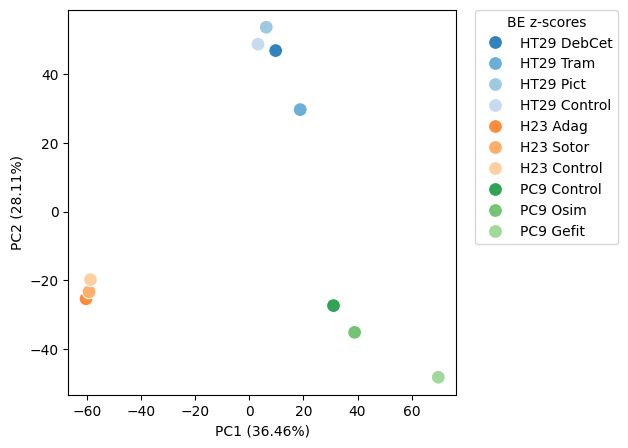

In [66]:
x_var, y_var = 0, 1

plt.figure(figsize=(5, 5))

sns.scatterplot(
    x=f"PC{x_var+1}",
    y=f"PC{y_var+1}",
    data=plot_df,
    hue="label",
    s=100,
    palette=palette_label,
)

# legend outside the plot no box
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0, title="BE z-scores")

plt.xlabel(f"PC{x_var+1} ({be_pca.explained_variance_ratio_[x_var]*100:.2f}%)")
plt.ylabel(f"PC{y_var+1} ({be_pca.explained_variance_ratio_[y_var]*100:.2f}%)")

#### PCA per mutations


In [67]:
n_components = 5

be_pca = PCA(n_components=n_components)
be_pcs = be_pca.fit_transform(StandardScaler().fit_transform(bs_fcs))

be_pcs = pd.DataFrame(
    be_pcs, columns=[f"PC{i+1}" for i in range(n_components)], index=bs_fcs.index
)

In [68]:
plot_df = be_pcs.reset_index()
plot_df

,guide,editor,PC1,PC2,PC3,PC4,PC5
0,GCCGGCGGCGGCGGCAGGAC,ABE,1.101105,-1.711315,0.241051,-0.602351,-0.194966
1,GCGGCAGGCGGCTGGCCCAG,ABE,0.428883,0.997734,-0.262924,0.541668,-0.163695
2,CCAGCGCACGCAGCGCGGCC,ABE,3.934876,-0.428352,-0.510387,-0.289556,-0.357719
3,GCGCACGCAGCGCGGCCCGA,ABE,1.186158,-1.800784,-0.280483,-0.661326,-0.409748
4,GAGCAGGCGGCCGAGCACCG,ABE,-0.653607,0.979588,0.283835,-0.319922,0.091430
...,...,...,...,...,...,...,...
3681,NGTACGAAGAACCCTATCTC,CBE,1.966930,-1.041196,0.623186,0.081912,-0.043470
3682,NTGCTCGGATCAAATCATCA,CBE,1.393210,-0.874830,0.640514,0.113435,0.282336
3683,NAGTCGCCACTCTCAGGTAG,CBE,1.229127,-0.141837,0.965924,0.435408,0.452559
3684,NAATTGAGACTAGAACGTAG,CBE,1.955472,-0.694140,0.601977,0.432920,-0.132218


Text(0, 0.5, 'PC2 (13.99%)')

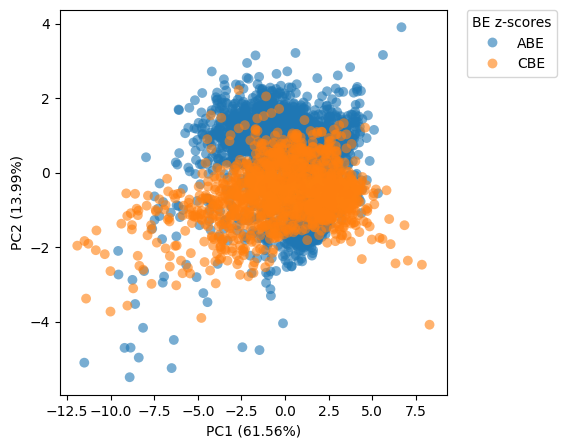

In [69]:
x_var, y_var = 0, 1

plt.figure(figsize=(5, 5))

sns.scatterplot(
    x=f"PC{x_var+1}",
    y=f"PC{y_var+1}",
    data=plot_df,
    hue="editor",
    s=50,
    lw=0,
    alpha=0.6,
    palette="tab10",
)

# legend outside the plot no box
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0, title="BE z-scores")

plt.xlabel(f"PC{x_var+1} ({be_pca.explained_variance_ratio_[x_var]*100:.2f}%)")
plt.ylabel(f"PC{y_var+1} ({be_pca.explained_variance_ratio_[y_var]*100:.2f}%)")

#### Clustermap


In [84]:
plot_df = bs_fcs.T.copy()

guide,GCCGGCGGCGGCGGCAGGAC,GCGGCAGGCGGCTGGCCCAG,CCAGCGCACGCAGCGCGGCC,GCGCACGCAGCGCGGCCCGA,GAGCAGGCGGCCGAGCACCG,CCCGCGCTCGCGCCCGGACG,GCCCGGACGCGGCGGCCCGG,ATTTCTTTGCTTTCCTAGTC,TCCTAGTCTGGGGAGCAGGG,ATCCATGGGTAGGAACACCA,...,NTCCGCTGTTGCACGAGAGT,NTACCTCCACCTACCCTAGT,NACATCCGTTGTCTTATCTA,NAATATCTACCCAACGACTA,NTAAGCAGATCATGAGCGGT,NGTACGAAGAACCCTATCTC,NTGCTCGGATCAAATCATCA,NAGTCGCCACTCTCAGGTAG,NAATTGAGACTAGAACGTAG,NGTCCGCACTTTATCAACAG
editor,ABE,ABE,ABE,ABE,ABE,ABE,ABE,ABE,ABE,ABE,...,CBE,CBE,CBE,CBE,CBE,CBE,CBE,CBE,CBE,CBE
L2FC_HT29_DebCet_plasmid_average_zscore,0.081899,-1.211400,3.734995,0.351586,-1.233796,0.144043,3.412038,-0.233232,-2.933702,-3.214261,...,-1.155921,-1.150414,-1.597107,-1.525848,1.441198,-0.496030,-0.621234,-1.663438,-1.204436,-0.057294
L2FC_HT29_Tram_plasmid_average_zscore,0.029328,-1.019983,0.949102,0.530953,-2.022724,0.483170,0.886702,0.202980,-2.410628,-3.490928,...,-1.020433,-0.637177,-2.220146,-0.816547,0.704841,0.460466,-0.764965,-1.045583,-0.030482,-0.562601
L2FC_HT29_Pict_plasmid_average_zscore,-0.119375,-1.090566,0.896700,0.270851,-2.280838,0.370997,0.913670,0.316790,-2.203627,-3.170051,...,-0.150347,-1.001035,-1.174614,-1.742233,1.506578,0.060817,-0.391584,-0.582299,0.224964,-0.046026
L2FC_HT29_Control_plasmid_average_zscore,-0.792538,-0.992708,0.799674,-0.345274,-2.557068,0.026665,0.624873,0.497048,-2.788206,-2.720605,...,-1.472689,-0.628660,-1.669072,-1.637119,1.331967,-0.408680,-0.471700,-0.991741,0.047169,-0.843412
L2FC_H23_Adag_plasmid_average_zscore,-1.778900,-0.345812,0.031541,-1.593466,-0.556686,-1.334163,-0.597061,-0.478537,-0.422077,-3.075104,...,-1.038189,-0.360612,-1.560583,-0.821233,1.883129,-0.665114,-0.753247,0.009729,-0.441428,0.279243
L2FC_H23_Sotor_plasmid_average_zscore,-0.785298,-0.251758,0.967282,-1.233367,0.061474,-0.349133,-0.362182,-1.422924,-0.509005,-1.233794,...,-1.112939,0.059048,-1.448880,-0.696991,0.812139,-0.636553,-0.524324,-0.407246,-0.317256,0.008813
L2FC_H23_Control_plasmid_average_zscore,-2.654073,1.100034,0.922145,-2.688182,-0.331360,-1.851240,-0.274619,-1.587406,-0.374254,-0.668988,...,-0.951558,-0.007839,-1.906580,-0.803130,0.536449,-0.801582,-1.129592,-0.216696,-0.533015,0.426373
L2FC_PC9_Control_plasmid_average_zscore,0.384193,-1.646028,1.144075,-0.048125,-2.015238,-0.080550,0.967238,0.489339,-2.616830,-2.214883,...,0.541810,0.788773,-1.194758,-0.685097,1.835228,0.481407,0.312933,0.085952,0.999911,0.484821
L2FC_PC9_Osim_plasmid_average_zscore,0.170199,-1.474372,0.951396,0.145557,-1.642339,0.005805,0.890025,0.400811,-2.026514,-2.866328,...,-0.001371,0.179737,-0.995321,-0.612760,1.006340,0.823789,0.045763,-0.236346,0.237703,1.085114


In [ ]:
row_labels = [" ".join(c.split("_")[1:3]) for c in plot_df.index]
row_colors = [palette_label[c] for c in row_labels]

In [87]:
col_colors = sns.color_palette("Set2", n_colors=2).as_hex()
col_colors = (
    plot_df.columns.get_level_values(1)
    .map({"ABE": col_colors[0], "CBE": col_colors[1]})
    .values
)

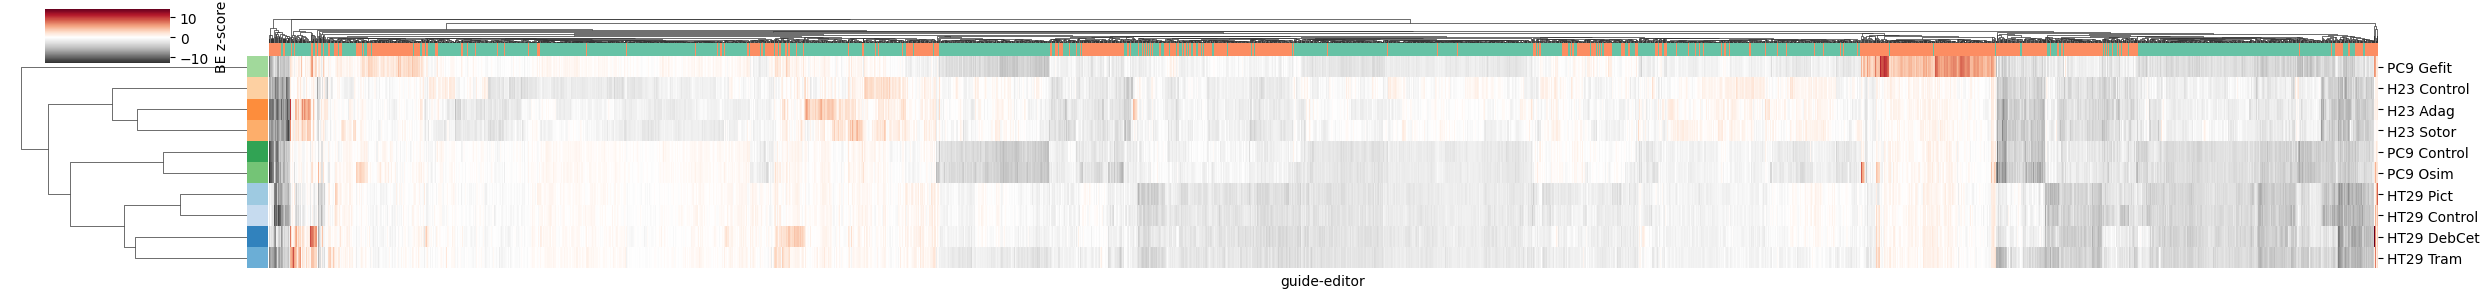

In [97]:
sns.clustermap(
    plot_df,
    cmap="RdGy_r",
    center=0,
    xticklabels=False,
    yticklabels=row_labels,
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.1, 0.1),
    colors_ratio=(0.009, 0.05),
    cbar_kws={"label": "BE z-score", "shrink": 0.2},
    figsize=(25, 3),
)

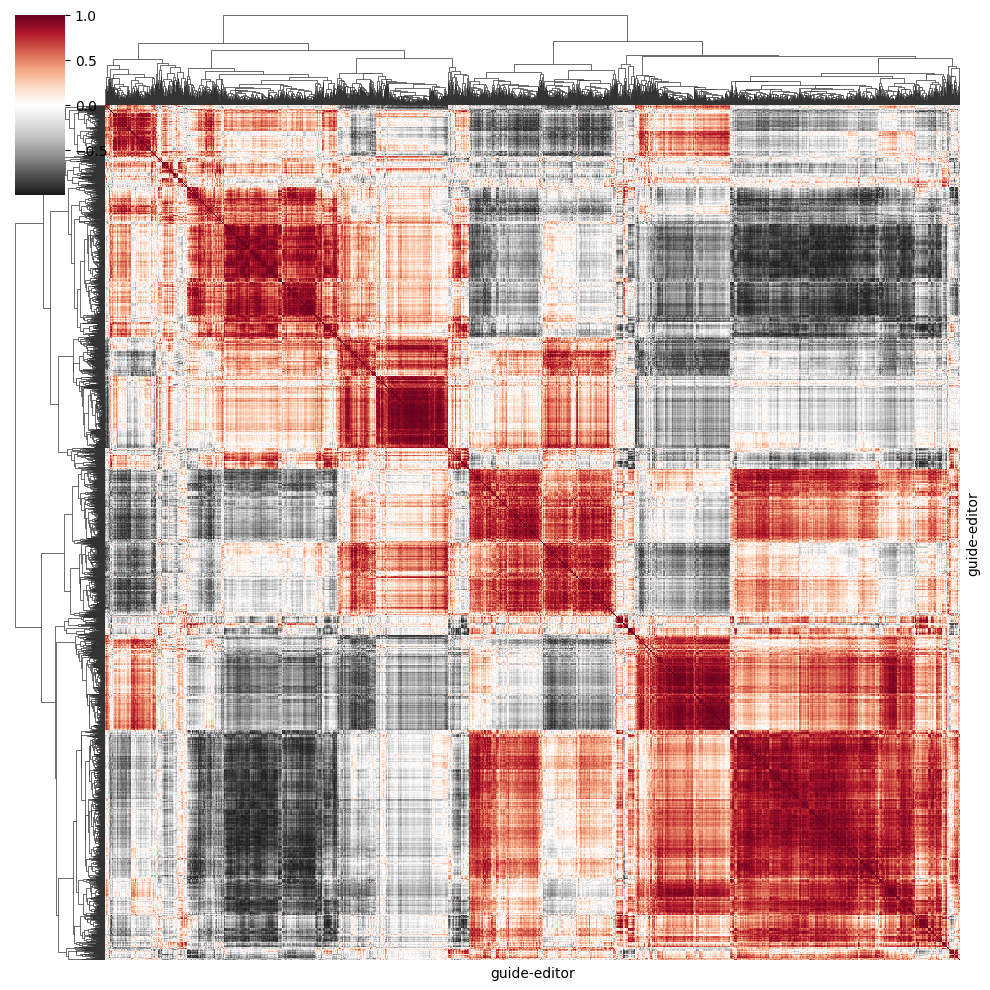

In [98]:
sns.clustermap(
    plot_df.corr(),
    cmap="RdGy_r",
    center=0,
    xticklabels=False,
    yticklabels=False,
    dendrogram_ratio=(0.1, 0.1),
    figsize=(10, 10),
)

## Import sgRNA Beagle Library


In [ ]:
variants_beagle = pd.read_csv(f"data/BeagleCoelho/EG_collab-guides-HGVS.txt", sep="\t")
variants_beagle["hgvs"] = variants_beagle["hgvs"].apply(
    lambda x: np.nan if x == "-" else ast.literal_eval(x)
)
variants_beagle.sample(10)

## Import Variants VEP


In [ ]:
variants_vep = pd.read_csv(
    f"data/BeagleCoelho/EG_collab-guides-VEP-HGVS-output.txt", sep="\t"
)
variants_vep.shape

In [ ]:
variants_vep = variants_vep.query("MANE == 'MANE_Select'")
variants_vep.shape

In [232]:
variants_vep["editor"] = (
    variants_vep["UPLOADED_ALLELE"]
    .apply(lambda v: "ABE" if v in {"G/A", "A/G"} else "CBE")
    .values
)

#### Number of guides per gene


In [233]:
plot_df = (
    variants_vep.groupby(["Feature", "SYMBOL"])["#Uploaded_variation"]
    .count()
    .sort_values(ascending=False)
).reset_index()
plot_df["Transcript length"] = plot_df["Feature"].map(transcript_length)

In [ ]:
_, ax = plt.subplots(figsize=(3, 3))

sns.scatterplot(
    data=plot_df,
    x="#Uploaded_variation",
    y="SYMBOL",
    size="Transcript length",
    sizes=(10, 100),
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles[1:],
    labels=labels[1:],
    title="Transcript length",
    title_fontsize="small",
    fontsize="small",
    frameon=False,
)

ax.grid(axis="x", linestyle=":", alpha=0.6)

ax.set_xlabel("Number of variants")
ax.set_ylabel("Gene")

## Merging DataFrames


### Input DataFrames

- **`variants_beagle`**: Contains sgRNA sequences, editors, and associated transcripts with keys (`sgRNA`, `editor`, `transcript`).
- **`variants_vep`**: Includes variant information with the key `#Uploaded_variation`.
- **`be_coelho`**: Represents sgRNA-editor pairs with keys (`sgRNA`, `editor`).

### Merging Steps

1. **Merge `be_coelho` with `variants_beagle`**:
   ```python
   be_merged = pd.merge(
       be_coelho.reset_index(),
       variants_beagle,
       left_on=["guide", "editor"],
       right_on=["sgRNA Sequence", "editor"],
       how="inner",
   )
   ```
2. **Merge `be_merged` with `variants_vep` after exploding `hgvs`**:
   ```python
    be_merged_vep = pd.merge(
        be_merged.dropna(subset=["hgvs"]).explode("hgvs"),
        variants_vep,
        left_on="hgvs",
        right_on="#Uploaded_variation",
        how="inner",
    )
   ```


In [235]:
be_merged = pd.merge(
    be_coelho.reset_index(),
    variants_beagle,
    left_on=["guide", "editor"],
    right_on=["sgRNA Sequence", "editor"],
    how="inner",
)

In [236]:
be_merged_vep = pd.merge(
    be_merged.dropna(subset=["hgvs"]).explode("hgvs"),
    variants_vep,
    left_on="hgvs",
    right_on="#Uploaded_variation",
    how="inner",
)

In [ ]:
be_merged_vep.sample(10)

Export combined dataset


In [238]:
be_merged_vep.to_csv("data/BeagleCoelho/BE_merged_vep.tsv", index=False, sep="\t")

## Predicting BE


In [ ]:
Y = be_merged_vep[[c for c in be_merged_vep if "average_zscore" in c]].dropna(axis=1)
Y.shape

In [160]:
X_mutfunc = be_merged_vep[[c for c in be_merged_vep if "mutfunc" in c]]

In [161]:
X_ClinPred = be_merged_vep[["ClinPred"]]

In [162]:
X_blosum = be_merged_vep[["BLOSUM62"]]

In [163]:
X_am_class = pd.get_dummies(be_merged_vep[["am_class"]]).astype(float)

In [164]:
X_cadd = be_merged_vep[["CADD_PHRED", "CADD_RAW"]]

In [165]:
e_func = r"\(([-+]?[0-9]*\.?[0-9]+)\)"

X_sift_poplyhen = pd.concat(
    [
        be_merged_vep["PolyPhen"].str.extract(e_func)[0].rename("PolyPhen"),
        be_merged_vep["SIFT"].str.extract(e_func)[0].rename("SIFT"),
    ],
    axis=1,
)

In [166]:
X_impact = pd.get_dummies(be_merged_vep[["IMPACT"]]).astype(float)

In [ ]:
X_sgrna = be_coelho_info.loc[
    [(g, e) for g, e in be_merged_vep[["guide", "editor_x"]].values]
].reset_index(drop=True)

X_sgrna = pd.concat(
    [
        pd.get_dummies(be_merged_vep["Gene"]).astype(float),
        X_sgrna.drop(columns=["Gene"]),
    ],
    axis=1,
)

In [216]:
X_crispr_fc = crispr.loc[
    ["SIDM00237", "SIDM00136", "SIDM00138"],
    be_coelho_info.loc[[(g, e) for g, e in be_merged_vep[["guide", "editor_x"]].values]]
    .reset_index(drop=True)["Gene"]
    .values,
].T.reset_index(drop=True)

In [217]:
X = (
    pd.concat(
        [
            X_mutfunc,
            X_ClinPred,
            X_blosum,
            X_am_class,
            X_cadd,
            X_sift_poplyhen,
            X_impact,
            X_sgrna,
            X_crispr_fc,
        ],
        axis=1,
    )
    .replace("-", np.nan)
    .astype(float)
)

In [ ]:
corr_matrix = pd.concat([X, Y], axis=1).corr()

sns.clustermap(
    corr_matrix.replace(np.nan, 0),
    cmap="vlag",
    annot=True,
    annot_kws={"fontsize": 6},
    fmt=".2f",
    mask=corr_matrix.isna(),
    figsize=(15, 15),
)

In [ ]:
import numpy as np
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Initialize the Support Vector Regressor
model = LinearRegression()

# Iterate through each variable in Y
for i, column in enumerate(Y.columns):
    # Extract the column as the target variable
    y_target = Y[column]

    # Perform 10-fold cross-validation and calculate R² scores for each fold
    r2_scores = cross_val_score(model, X, y_target, cv=10, scoring="r2", n_jobs=-1)

    # Report the R² scores for the current variable
    print(f"  Mean R² score: {np.mean(r2_scores):.4f}")
    print(f"  Standard deviation of R² scores: {np.std(r2_scores):.4f}\n")